In [1]:
import scanpy as sc 
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA

import scipy.sparse as sp 
import warnings
import torch

warnings.filterwarnings("ignore")

import os
import ctypes
import sys

os.environ["R_HOME"] = "/home/pxy/miniconda3/envs/r40/lib/R"

try:
    libR_path = "/home/pxy/miniconda3/envs/r40/lib/R/lib/libR.so"
    ctypes.CDLL(libR_path, mode=ctypes.RTLD_GLOBAL)
    print("✅ 成功强制加载 libR.so")
except OSError as e:
    print(f"❌ 加载失败: {e}")

sys.path.append("..") 

import models
import rpy2.robjects as robjects
print("R 环境路径:", robjects.r['R.home']()[0])

models.fix_seed(0)

✅ 成功强制加载 libR.so
R 环境路径: /home/pxy/miniconda3/envs/r40/lib/R


In [2]:
import scanpy as sc
import pandas as pd
import os

sample_name = "Mouse_Brain_Anterior_Section1"  
data_dir  = '/home/pxy/home/pxy/data/'
data_path = os.path.join(data_dir, sample_name)


adata = sc.read_visium(data_path)
adata.var_names_make_unique()
print(adata)


meta = pd.read_csv(
    os.path.join(data_path, "metadata.tsv"),
    sep="\t",
    index_col=0 
)

adata.obs["Region"] = meta.loc[adata.obs_names, "ground_truth"]

print("\n各层数量：")
print(adata.obs["Region"].value_counts())
print("NA spots:", adata.obs["Region"].isna().sum())

AnnData object with n_obs × n_vars = 2695 × 32285
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

各层数量：
Region
CPu              323
MO::L5           191
MO::L2/3         160
MOB::Gr          116
AcbC             109
SS::L5           103
Pal::Sl           89
CC                87
MO::L6            79
MOB::Gl_1         75
SS::L2/3          75
MOB::Opl          73
MO::L1            72
Pal::MA           65
TH::RT            61
Pal::NDB          59
OT::Ml            57
AcbSh             52
ORB::L2/3         43
PIR               43
OT::PoL           40
SS::L1            40
ORB::L5           40
SS::L6            39
OT::Pl            39
St                38
Cl                37
Pal::GPi          31
HY::LPO           31
Fim               29
AON::L1_1         28
AON::L2           28
ORB::L6           28
ORB::L1           26
AOE               25
AON::L1_2         25
Or                24
En                22
FRP::

In [3]:
n_clusters = adata.obs["Region"].nunique() 
print(f"真实空间域数量：{n_clusters}")

真实空间域数量：52


In [4]:
adata = models.preprocess(adata)
adata.obsm["X_pca"] = PCA(n_components=200, random_state=0).fit_transform(adata.X)
g_spatia = models.prepare_graph(adata, "spatial",n_neighbors=6)
g_expr = models.prepare_graph(adata, "expr",n_neighbors=12, metric="euclidean")
graph_dict = {"spatial": g_spatia, "expr":g_expr}

Preprocessing data ---------------->
正在构建图: spatial, 使用度量: cosine ...
  -> 使用空间坐标 (euclidean)
  -> 计算最近邻 (NearestNeighbors)...
  -> 对称化与归一化...
spatial graph created successfully <----

正在构建图: expr, 使用度量: euclidean ...
  -> 使用 PCA 表达特征
  -> 计算最近邻 (NearestNeighbors)...
  -> 对称化与归一化...
expr graph created successfully <----



In [6]:
model = models.model_TwoStage(
            adata.obsm["X_pca"], 
            graph_dict, 
            n_clusters=n_clusters,
            pretrain_epochs=100,
            finetune_epochs=100,
            gamma=0.0,
            theta=1.0,
            kappa=1.5,
            graph_corr=0.0,
            dropout=0.1,
            gate_bias=1.0,
            residual_weight=0.2,
            freeze_encoder=False,
            dim_input=200
        )

In [7]:
pred, embed, gated_weights = model.train()

Stage 1: Pre-training Shared Encoder


Pretrain:  34%|███▍      | 34/100 [00:02<00:02, 22.20it/s]

  Pretrain Epoch 10: Rec Loss = 22.240835
  Pretrain Epoch 20: Rec Loss = 21.289982
  Pretrain Epoch 30: Rec Loss = 19.839367
  Pretrain Epoch 40: Rec Loss = 19.329975


Pretrain:  70%|███████   | 70/100 [00:02<00:00, 55.19it/s]

  Pretrain Epoch 50: Rec Loss = 19.085230
  Pretrain Epoch 60: Rec Loss = 18.923983
  Pretrain Epoch 70: Rec Loss = 18.784462
  Pretrain Epoch 80: Rec Loss = 18.688475


...

  Train Epoch 80: Loss = 11.605895,Rec Loss = 22.578978, Contrast Loss = 7.707550, Smooth Loss = 0.044570


Finetune:  91%|█████████ | 91/100 [00:05<00:00, 15.47it/s]

  Train Epoch 90: Loss = 11.594731,Rec Loss = 22.588865, Contrast Loss = 7.702984, Smooth Loss = 0.040255


Finetune: 100%|██████████| 100/100 [00:06<00:00, 14.89it/s]

  Train Epoch 100: Loss = 11.587474,Rec Loss = 22.597109, Contrast Loss = 7.700611, Smooth Loss = 0.036558

  Finetune Epoch 100:
    Total Loss   = 11.5875
    Rec Loss     = 22.5971
    Contrast Loss = 7.7006
    Smooth Loss = 0.0366

✓ Finetune finished (max epochs reached)


In [8]:
# ========== 聚类 ==========
adata.obsm["model_twostage"] = embed
models.clustering(adata, n_clusters, key="model_twostage", refinement=True,cluster_methods='kmeans')

# ========== 评估 ==========
# adata_filtered = adata[adata.obs.Region.notna()]
# ARI_kmeans = adjusted_rand_score(adata_filtered.obs["Region"], 
#                         adata_filtered.obs["kmeans_refined"])
valid_mask = adata.obs["Region"].notna()
adata_filtered = adata[valid_mask]
ARI_kmeans = adjusted_rand_score(
    adata_filtered.obs["Region"], 
    adata_filtered.obs["kmeans_refined"]
)
print(f"\nFinal Kmeans ARI on {sample_name}: {ARI_kmeans:.8f}")


Final Kmeans ARI on Mouse_Brain_Anterior_Section1: 0.44936037


In [9]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score
mask = adata.obs.Region.notna()
X = embed[mask]
labels = adata.obs["kmeans_refined"][mask]

# 1. 计算 SC 指数
sc_val = silhouette_score(X, labels)

# 2. 计算 CH 指数
ch_val = calinski_harabasz_score(X, labels)

print(f"Internal Evaluation for {sample_name}:")
print(f"Silhouette Coefficient (SC): {sc_val:.4f}")
print(f"Calinski-Harabasz Index (CH): {ch_val:.4f}")

Internal Evaluation for Mouse_Brain_Anterior_Section1:
Silhouette Coefficient (SC): 0.1496
Calinski-Harabasz Index (CH): 1416.8729


In [10]:
from sklearn.metrics import normalized_mutual_info_score

adata_filtered = adata[adata.obs.Region.notna()]

NMI_kmeans = normalized_mutual_info_score(adata_filtered.obs["Region"], 
                                          adata_filtered.obs["kmeans_refined"])

print(f"\nFinal Results on {sample_name}:")
print(f"ARI: {ARI_kmeans:.4f}")
print(f"NMI: {NMI_kmeans:.4f}")


Final Results on Mouse_Brain_Anterior_Section1:
ARI: 0.4494
NMI: 0.6887


In [11]:
# ========== 聚类 ==========
adata.obsm["model_twostage"] = embed
models.clustering(adata, n_clusters, key="model_twostage", refinement=True)

# ========== 评估 ==========
adata_filtered = adata[adata.obs.Region.notna()]
ARI_mclust = adjusted_rand_score(adata_filtered.obs["Region"], 
                          adata_filtered.obs["mclust_refined"])
print(f"\nFinal ARI on {sample_name}: {ARI_mclust:.4f}")


R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%

Final ARI on Mouse_Brain_Anterior_Section1: 0.3418


In [12]:
NMI_mclust = normalized_mutual_info_score(adata_filtered.obs["Region"], 
                                          adata_filtered.obs["mclust_refined"])

print(f"\nFinal Results on {sample_name}:")
print(f"ARI: {ARI_mclust:.4f}")
print(f"NMI: {NMI_mclust:.4f}")


Final Results on Mouse_Brain_Anterior_Section1:
ARI: 0.3418
NMI: 0.6857


In [13]:
import matplotlib.pyplot as plt
import scanpy as sc

# # 1. 准备数据
figures_dir = "figures_MBA"

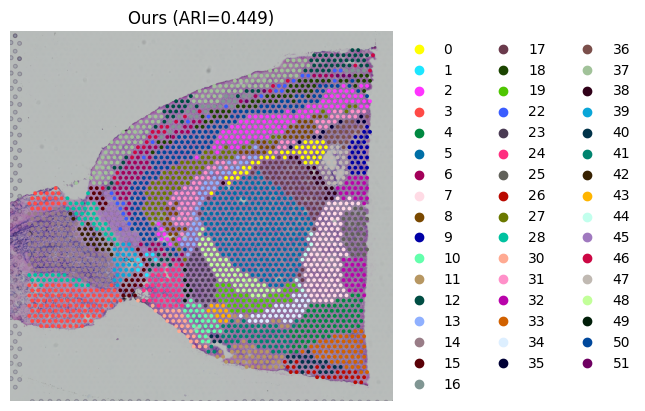

In [14]:
adata.obs["model"] = adata.obs["kmeans_refined"]

ax = sc.pl.spatial(
    adata, 
    color=["model"], 
    frameon=False, 
    show=False, 
    title=[f"Ours (ARI={round(ARI_kmeans, 3)})"]
)


# 4. 保存与显示
plt.savefig(f"{figures_dir}/MBA_spatial_preprocess_kmeans_{n_clusters}Clusters_3.png", bbox_inches='tight', dpi=300)
plt.show()
plt.close()


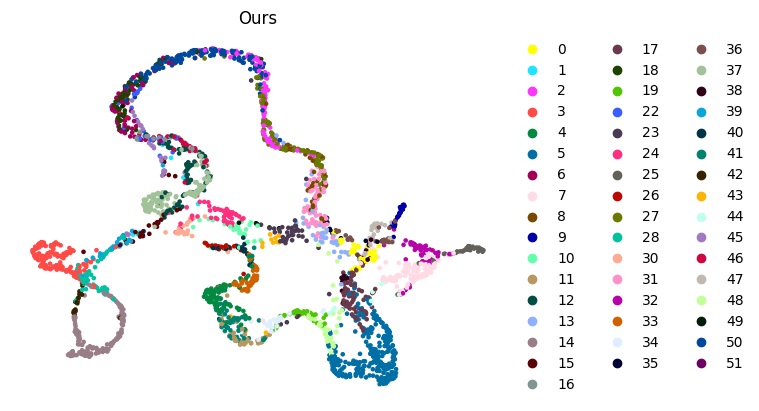

In [21]:
# 计算 UMAP
adata.obsm["embed"] = embed
sc.pp.neighbors(adata, n_neighbors=15, use_rep="embed")
sc.tl.umap(adata)
sc.pl.umap(adata, color=["kmeans_refined"], 
           title=["Ours"],
            frameon=False,       # 去掉外框，论文图更美观
           show=False) # <--- 关键：改为 False

# 3. 保存图片：此时画布上还有内容
plt.savefig(f"{figures_dir}/{sample_name}_umap_3_without_frame.png", bbox_inches='tight')

# 4. 最后再显示并关闭
plt.show() 
plt.close()

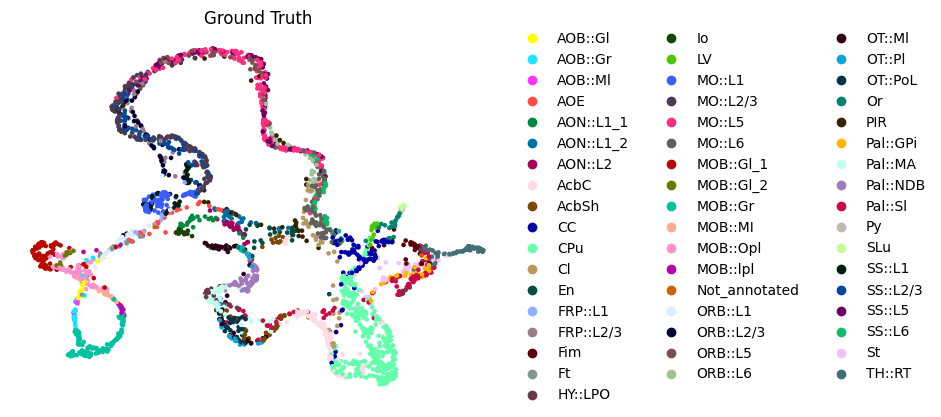

In [20]:
sc.pl.umap(adata, 
           color=["Region"], 
           title=["Ground Truth"],
           frameon=False,       # 去掉外框，论文图更美观
           show=False) 

# 3. 保存图片：文件名建议区分开，比如加个 _gt 后缀
plt.savefig(f"{figures_dir}/{sample_name}_umap_gt.png", bbox_inches='tight')

# 4. 显示并关闭
plt.show() 
plt.close()